# Whakaari Cause–Trigger Analysis

This notebook runs the Cause–Trigger algorithm on the Whakaari dataset using three causal-discovery backends:

1. **HMML** — baseline.
2. **PCMCI** — lagged causal-discovery sensitivity backend.
3. **PCMCI+** — lagged + contemporaneous causal-discovery backend.

## 1. Imports and paths

In [12]:
from pathlib import Path
import sys
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "whakaari"

for path in [SRC_DIR, NOTEBOOK_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

from cause_trigger_whakaari import *

WHAKAARI_ERUPTION_TIME = pd.Timestamp("2019-12-09 01:11", tz="UTC")
WHAKAARI_PATH = DATA_DIR / "whakaari_final.csv"

In [13]:
X = load_model_frame(WHAKAARI_PATH)
display(pd.DataFrame([model_overview(X, EFFECT)]))

,n_rows,n_variables,start,end,inferred_frequency,effect,effect_min,effect_median,effect_mean,effect_max,effect_abs_mean,effect_iqr,effect_n_unique
0,1678,8,2019-10-01 00:00:00+00:00,2019-12-12 23:00:00+00:00,None,effect_tremor_5_15_scaled,-3.461211,-0.034775,4.065084e-16,15.766081,0.661228,1.019055,1678


## 2. Automatic parameter selection, Main configuration and split check

In [14]:
params = select_parameters(
    X,
    EFFECT,
    max_lags=6,
    criterion="aic",
    fallback_lag=1,
)

display(pd.DataFrame([params]))

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,effect,selected_lag,selected_distribution,lag_method,max_lags,fallback_lag,fallback_distribution
0,effect_tremor_5_15_scaled,4,gaussian,VAR-AIC,6,1,gaussian


In [15]:
workflow = WhakaariWorkflowConfig(
    effect=EFFECT,
    event_time=WHAKAARI_ERUPTION_TIME,
    selected_lag=params["selected_lag"],
    distribution=params["selected_distribution"],
    parameter_source="var_aic_distfit",
    alpha=0.05,
    min_I1_length=48,
    min_I2_length=48,
)

,effect,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,event_time,distance_to_event,boundary_split
0,effect_tremor_5_15_scaled,1630,2019-12-10 22:00:00+00:00,1630,48,0.086977,2.953604,2.866627,2019-12-09 01:11:00+00:00,1 days 20:49:00,True


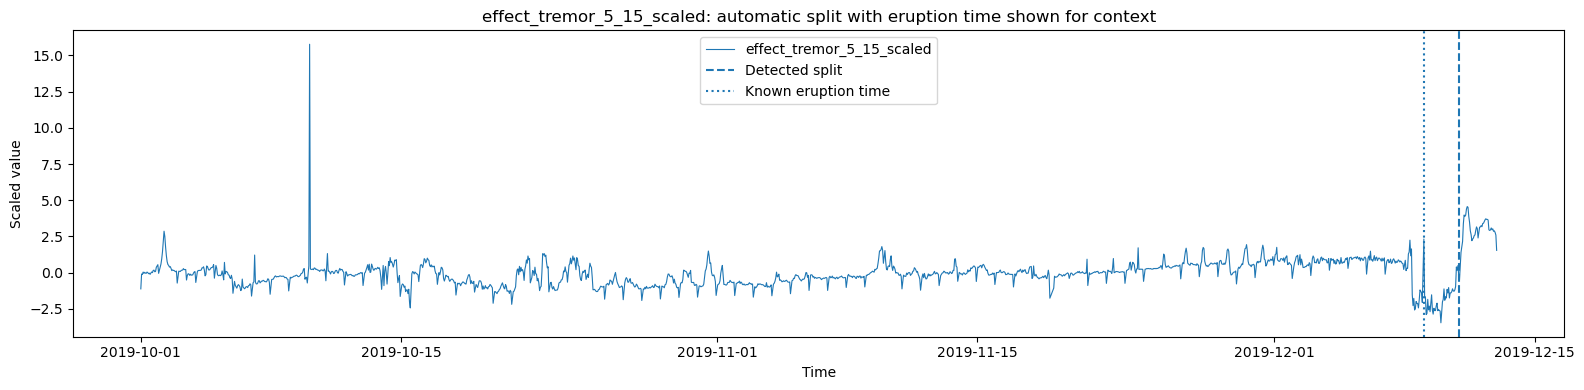

In [16]:
split_row = split_diagnostics(
    X,
    EFFECT,
    event_time=workflow.event_time,
    min_I1_length=workflow.min_I1_length,
    min_I2_length=workflow.min_I2_length,
)

display(pd.DataFrame([split_row]))

plot_effect_with_split(
    X,
    EFFECT,
    split_row,
    event_time=workflow.event_time,
)

## 3. Main run

HMML is the baseline. PCMCI/PCMCI+ are extensions.

In [17]:
results, comparison, diagnostics = run_suite(
    X,
    workflow,
    lag=workflow.selected_lag,
    distribution=workflow.distribution,
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.649e-03, tolerance: 4.363e-04
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the f

In [18]:
display(compact_comparison(comparison))
#display(comparison)

,run,backend,configured_lags,configured_distribution,split_timestamp,I1_length,I2_length,B2,trigger_candidates,accepted_triggers,causes,pairs,stop_reason
0,hmml_backend_beta,hmml,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[event_rate_2_5_scaled, ratio_4p5_8_over_8_16_...","[(event_rate_2_5_scaled, ratio_4p5_8_over_8_16...",None
1,pcmci_ridge,pcmci,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[effect_tremor_5_15_scaled, SO2_flux_scaled]",[SO2_flux_scaled],[],[],[],None
2,pcmci_adaptive_lasso,pcmci,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[effect_tremor_5_15_scaled, SO2_flux_scaled]",[SO2_flux_scaled],[],[],[],None
3,pcmci_plus_ridge,pcmci_plus,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,[effect_tremor_5_15_scaled],[],[],[],[],Not enough B2 variables for cause selection.
4,pcmci_plus_adaptive_lasso,pcmci_plus,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,[effect_tremor_5_15_scaled],[],[],[],[],Not enough B2 variables for cause selection.


In [19]:
display(compact_diagnostics(diagnostics))
#display(diagnostics)

,run,trigger,cause,accepted,p_value,f_stat,critical_f,rss_reduction_ratio,gamma_2,backend
0,hmml_backend_beta,ratio_4p5_8_over_8_16_scaled,event_rate_2_5_scaled,True,0.000010,25.310501,4.078546,0.381697,-1.256768,hmml
1,hmml_backend_beta,event_rate_2_5_scaled,ratio_4p5_8_over_8_16_scaled,True,0.044817,4.283808,4.078546,0.094599,0.571333,hmml
2,hmml_backend_beta,SO2_flux_scaled,event_rate_2_5_scaled,True,0.043116,4.356928,4.078546,0.096059,0.377550,hmml
3,pcmci_ridge,SO2_flux_scaled,None,False,NaN,NaN,NaN,NaN,NaN,pcmci
4,pcmci_adaptive_lasso,SO2_flux_scaled,None,False,NaN,NaN,NaN,NaN,NaN,pcmci


### PCMCI+ run

In [ ]:
result_tau0, diag_tau0, row_tau0 = run_one(
    X,
    workflow,
    run_name="pcmci_plus_tau0_ridge",
    backend="pcmci_plus",
    refit_method="ridge",
    parameter_source="automatic_pcmci_plus_tau0_ridge",
    use_contemporaneous_triggers=True,
)

## 4. Sensitivity check

In [20]:
sensitivity = run_sensitivity_grid(
    X,
    workflow,
    lags=range(1, workflow.max_lags + 1),
    distributions=(workflow.distribution,),
    cond_ind_test="parcorr",
)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) *

In [21]:
display(compact_sensitivity(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
0,hmml_backend_beta,hmml,1,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...",[ratio_4p5_8_over_8_16_scaled],[event_rate_2_5_scaled],"[(event_rate_2_5_scaled, ratio_4p5_8_over_8_16...",None
1,hmml_backend_beta,hmml,2,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[event_rate_2_5_scaled, hydro_2_5_scaled]","[(event_rate_2_5_scaled, hydro_2_5_scaled), (h...",None
2,hmml_backend_beta,hmml,3,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[ratio_4p5_8_over_8_16_scaled, API_scaled]",[hydro_2_5_scaled],"[(hydro_2_5_scaled, ratio_4p5_8_over_8_16_scal...",None
3,hmml_backend_beta,hmml,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[event_rate_2_5_scaled, ratio_4p5_8_over_8_16_...","[(event_rate_2_5_scaled, ratio_4p5_8_over_8_16...",None
4,hmml_backend_beta,hmml,5,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled]","[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scal...",None
5,hmml_backend_beta,hmml,6,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[event_rate_2_5_scaled, hydro_2_5_scaled]","[(event_rate_2_5_scaled, hydro_2_5_scaled), (h...",None
6,pcmci_ridge,pcmci,1,gaussian,2019-12-10 22:00:00+00:00,1630,48,[effect_tremor_5_15_scaled],[],[],[],[],None
7,pcmci_ridge,pcmci,2,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[effect_tremor_5_15_scaled, SO2_flux_scaled]",[SO2_flux_scaled],[],[],[],None
8,pcmci_ridge,pcmci,3,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[effect_tremor_5_15_scaled, SO2_flux_scaled]",[SO2_flux_scaled],[],[],[],None
9,pcmci_ridge,pcmci,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[effect_tremor_5_15_scaled, SO2_flux_scaled]",[SO2_flux_scaled],[],[],[],None


In [22]:
display(accepted_sensitivity_rows(sensitivity))

,run,backend,lag,distribution,split_timestamp,I1_length,I2_length,B_2,trigger_candidates,accepted_triggers,causes,pairs,error
0,hmml_backend_beta,hmml,1,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...",[ratio_4p5_8_over_8_16_scaled],[event_rate_2_5_scaled],"[(event_rate_2_5_scaled, ratio_4p5_8_over_8_16...",None
1,hmml_backend_beta,hmml,2,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[event_rate_2_5_scaled, hydro_2_5_scaled]","[(event_rate_2_5_scaled, hydro_2_5_scaled), (h...",None
2,hmml_backend_beta,hmml,3,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[ratio_4p5_8_over_8_16_scaled, API_scaled]",[hydro_2_5_scaled],"[(hydro_2_5_scaled, ratio_4p5_8_over_8_16_scal...",None
3,hmml_backend_beta,hmml,4,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[ratio_4p5_8_over_8_16_scaled, event_rate_2_5_...","[event_rate_2_5_scaled, ratio_4p5_8_over_8_16_...","[(event_rate_2_5_scaled, ratio_4p5_8_over_8_16...",None
4,hmml_backend_beta,hmml,5,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[ratio_4p5_8_over_8_16_scaled, hydro_2_5_scaled]","[(ratio_4p5_8_over_8_16_scaled, hydro_2_5_scal...",None
5,hmml_backend_beta,hmml,6,gaussian,2019-12-10 22:00:00+00:00,1630,48,"[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[hydro_2_5_scaled, ratio_4p5_8_over_8_16_scale...","[event_rate_2_5_scaled, hydro_2_5_scaled]","[(event_rate_2_5_scaled, hydro_2_5_scaled), (h...",None
